## 1. Setup

In [1]:
%matplotlib inline
# %matplotlib widget   # also works if you have ipympl installed

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

# iSLAT data types
from iSLAT.Modules.DataTypes import MoleculeDict

# iSLAT standalone plot classes
from iSLAT.Modules.Plotting import (
    BasePlot,
    load_theme,
    PopulationDiagramPlot,
    MainPlotGrid,
)

print("Imports successful!")
print(f"matplotlib backend: {matplotlib.get_backend()}")

Imports successful!
matplotlib backend: inline


In [2]:
# --- Load observed data and create molecules ---
from iSLAT.Modules.FileHandling import example_data_folder_path, hitran_data_folder_path

# Load CI Tau MIRI spectrum (Banzatti+2023b)
data_path = example_data_folder_path / "CITau_MIRI_Banzatti+2023b.csv"
obs = pd.read_csv(data_path)

wave_grid     = obs["wave"].values
observed_flux = obs["flux"].values
observed_err  = obs["err"].values
continuum     = obs["cont"].values

print(f"Loaded: {data_path.name}")
print(f"  {len(wave_grid)} points, {wave_grid.min():.2f}-{wave_grid.max():.2f} um")

# Paths to HITRAN parameter files
data_dir = hitran_data_folder_path
water_par_file = str(data_dir / "data_Hitran_H2O.par")
co_par_file    = str(data_dir / "data_Hitran_CO.par")
co2_par_file   = str(data_dir / "data_Hitran_CO2.par")

# Build a MoleculeDict with three molecules
wavelength_range = (float(wave_grid.min()), float(wave_grid.max()))

mol_dict = MoleculeDict(
    global_distance=160,
    global_stellar_rv=0.0,
    global_wavelength_range=wavelength_range,
    global_model_pixel_res=0.0013,
)

molecules_to_create = {
    "H2O": {"Molecule Name": "H2O", "temp": 850, "n_mol": 1e18, "radius": 0.5, "color": "#0000FF",
             "displaylabel": "$H_2O$", "File Path": water_par_file},
    "CO":  {"Molecule Name": "CO",  "temp": 1000, "n_mol": 1e18, "radius": 0.4, "color": "#FF0000",
             "displaylabel": "CO",  "File Path": co_par_file},
    "CO2": {"Molecule Name": "CO2", "temp": 300,  "n_mol": 1e17, "radius": 0.5, "color": "green",
             "displaylabel": "$CO_2$", "File Path": co2_par_file},
}

mol_dict.load_molecules(
    molecules_data=[v for v in molecules_to_create.values()],
    initial_molecule_parameters=molecules_to_create,
)

# Set all FWHM values to 130, and all broadings to 1
mol_dict.bulk_update_parameters({"fwhm": 130, "broad": 1})

print(f"MoleculeDict: {list(mol_dict.keys())}")
print(f"Observed data: {len(wave_grid)} points, {wave_grid.min():.2f}-{wave_grid.max():.2f} um")

Loaded: CITau_MIRI_Banzatti+2023b.csv
  10672 points, 4.90-28.72 um
Deferring intensity calculations for 3 molecules
MoleculeDict: ['H2O', 'CO', 'CO2']
Observed data: 10672 points, 4.90-28.72 um


---
## 2. Single Molecule — Basic Population Diagram

The simplest usage: pass a single `Molecule` to create a classic Boltzmann / rotation diagram.

The y-axis is $\ln\!\bigl(4\pi F / (h\nu\, A_u\, g_u)\bigr)$ and the x-axis is $E_u$ (K).

By default, single-molecule mode uses the theme's **neutral scatter colour** (`scatter_main_color`, a grey tone) — matching the original iSLAT behaviour.
To colour the points by molecule identity instead, use `color_by("molecule")` (see Section 6).

Calculating intensity for H2O: T=850.0K, N_mol=1.00e+18, dv=1.0


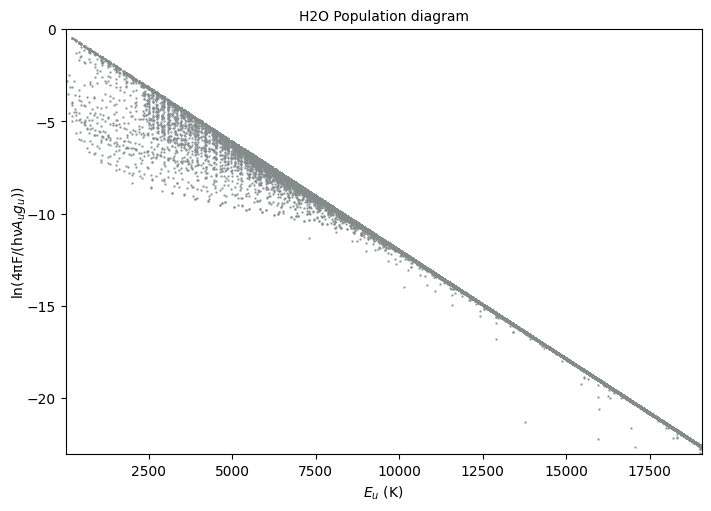

In [3]:
# --- Basic single-molecule population diagram ---

pdp = PopulationDiagramPlot(
    molecule=mol_dict["H2O"],
    figsize=(7, 5),
)
pdp.generate_plot()
pdp.show()

Calculating intensity for CO: T=1000.0K, N_mol=1.00e+18, dv=1.0


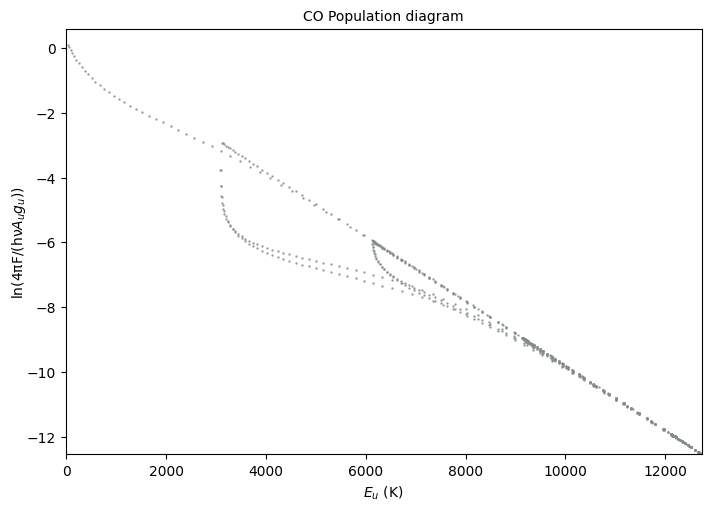

In [4]:
# --- Switch molecule in-place with set_molecule() ---

pdp.set_molecule(mol_dict["CO"])   # regenerates automatically
pdp.show()

---
## 3. Multiple Molecules — List

Pass a **list** of `Molecule` objects to overlay them on the same diagram.
Each molecule is automatically colour-coded using its `.color` attribute.
If molecules share the same colour, the default colour cycle kicks in to
ensure visual distinction.

Calculating intensity for CO2: T=300.0K, N_mol=1.00e+17, dv=1.0


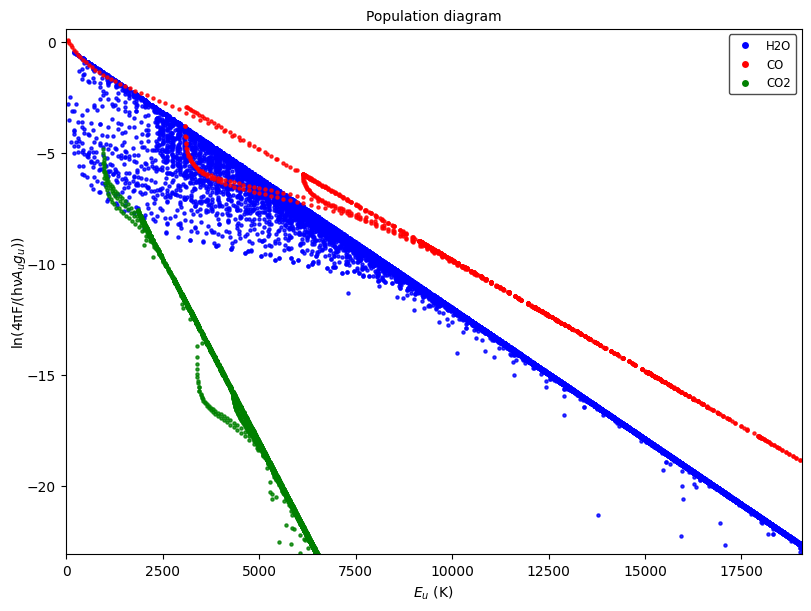

In [5]:
# --- Multi-molecule population diagram from a list ---

pdp_multi = PopulationDiagramPlot(
    molecules=[mol_dict["H2O"], mol_dict["CO"], mol_dict["CO2"]],
    figsize=(8, 6),
)
pdp_multi.generate_plot()
pdp_multi.show()

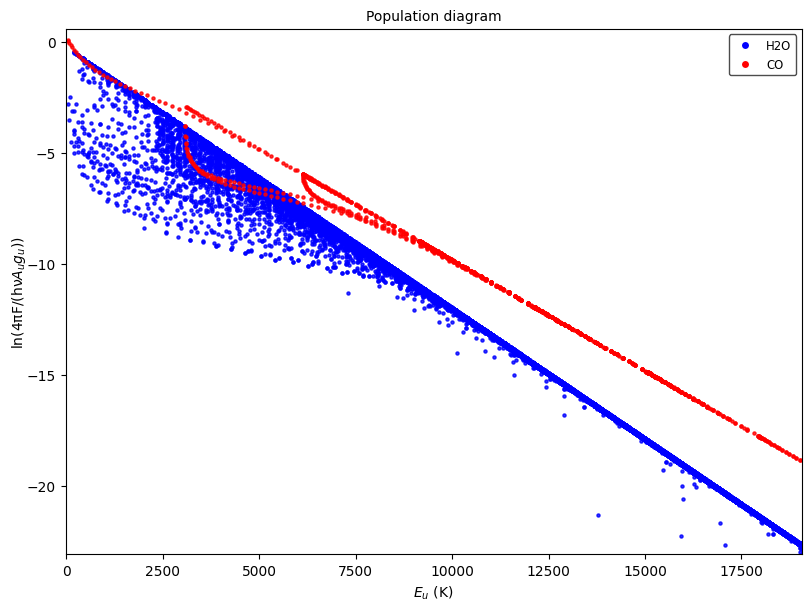

In [6]:
# --- You can also pass just two molecules ---

pdp_two = PopulationDiagramPlot(
    molecules=[mol_dict["H2O"], mol_dict["CO"]],
    figsize=(8, 6),
)
pdp_two.generate_plot()
pdp_two.show()

---
## 4. Multiple Molecules — MoleculeDict

Pass the full `MoleculeDict` and the plot automatically extracts all **visible** molecules.
This is the most convenient path when working with a full model.

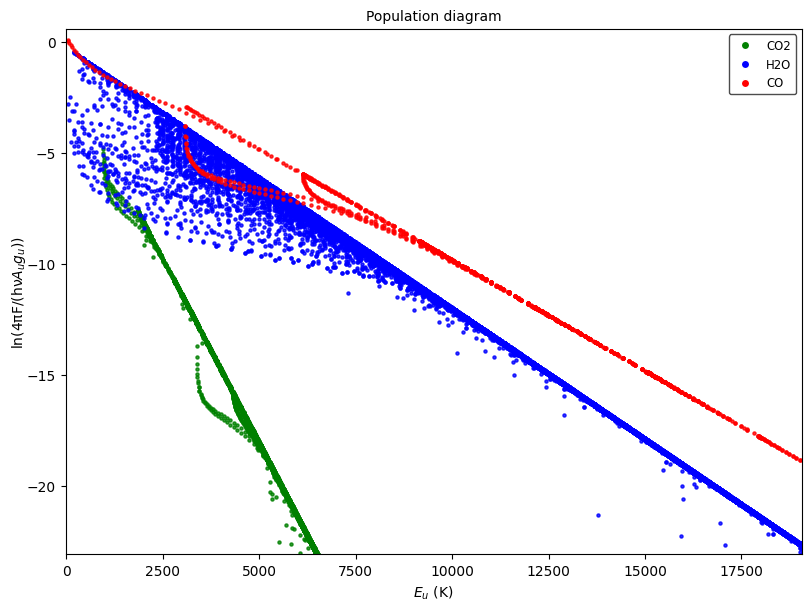

In [7]:
# --- Multi-molecule from MoleculeDict ---

pdp_dict = PopulationDiagramPlot(
    molecules=mol_dict,   # all visible molecules are extracted
    figsize=(8, 6),
)
pdp_dict.generate_plot()
pdp_dict.show()

---
## 5. Bare Intensity Path

If you have a pre-computed `Intensity` object but not a full `Molecule`, you can
pass it directly with the required physical metadata (`radius`, `distance`).

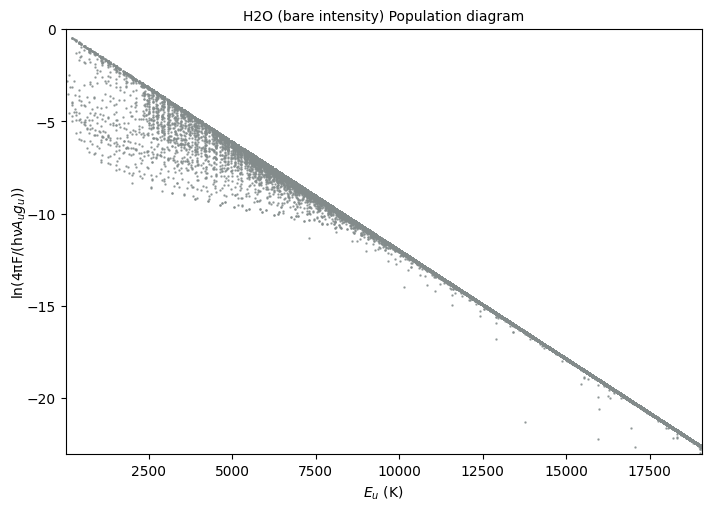

In [8]:
# --- Population diagram from a bare Intensity object ---

h2o = mol_dict["H2O"]
h2o.calculate_intensity()   # ensure intensity is computed

pdp_bare = PopulationDiagramPlot(
    intensity=h2o.intensity,
    name="H2O (bare intensity)",
    color="darkorange",
    radius=h2o.radius,
    distance=h2o.distance,
    figsize=(7, 5),
)
pdp_bare.generate_plot()
pdp_bare.show()

---
## 6. Colour Mapping — Continuous Properties

Use `color_by()` to re-colour the scatter points by a **continuous molecular property**.
A colourbar is automatically added to the figure.

Since $E_u$ is already on the x-axis, the most informative colour maps typically use a
*different* property — such as wavelength, Einstein A coefficient, or intensity — so
you can see correlations between the two dimensions.

### Supported continuous properties:

| `prop` value | Description |
|---|---|
| `'a_stein'` | Einstein A coefficient $A_u$ (s⁻¹) |
| `'wavelength'` or `'lam'` | Line wavelength (μm) |
| `'intens'` | Model intensity |
| `'g_up'` | Upper-state degeneracy $g_u$ |
| `'g_low'` | Lower-state degeneracy $g_{low}$ |
| `'e_up'` | Upper-level energy $E_u$ (K) — *same as x-axis* |
| `'e_low'` | Lower-level energy $E_{low}$ (K) |

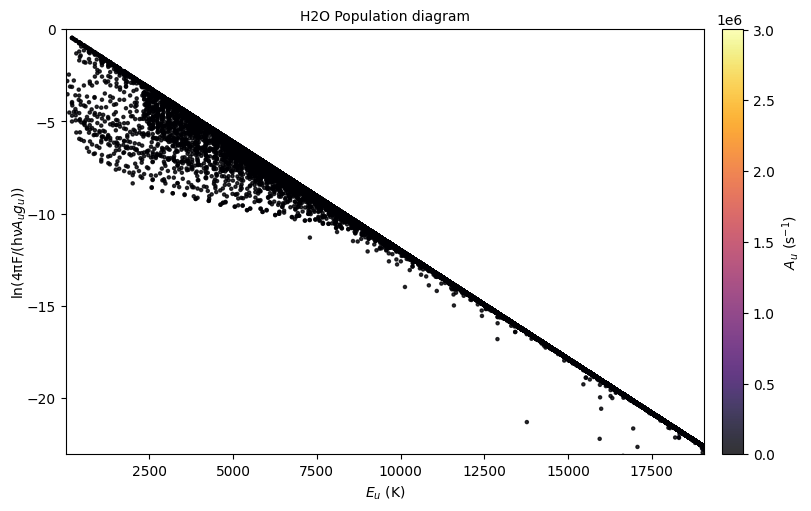

In [9]:
# --- Colour by Einstein A coefficient ---
# Highlights which transitions are intrinsically strongest

pdp_cmap = PopulationDiagramPlot(
    molecule=mol_dict["H2O"],
    figsize=(8, 5),
)
pdp_cmap.generate_plot()

# Apply colour mapping (regenerates automatically)
pdp_cmap.color_by("a_stein", cmap="inferno")
pdp_cmap.show()

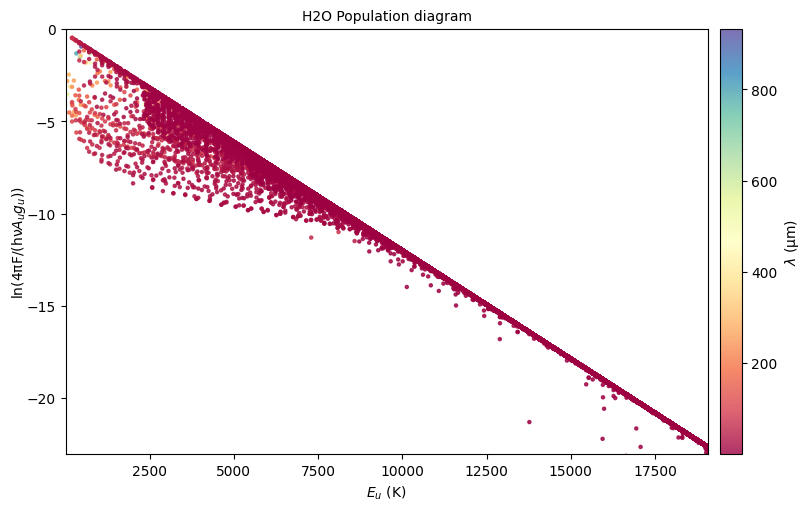

In [10]:
# --- Colour by wavelength ---
# Shows where in the spectrum each transition falls

pdp_wave = PopulationDiagramPlot(
    molecule=mol_dict["H2O"],
    figsize=(8, 5),
)
pdp_wave.generate_plot()
pdp_wave.color_by("wavelength", cmap="Spectral")
pdp_wave.show()

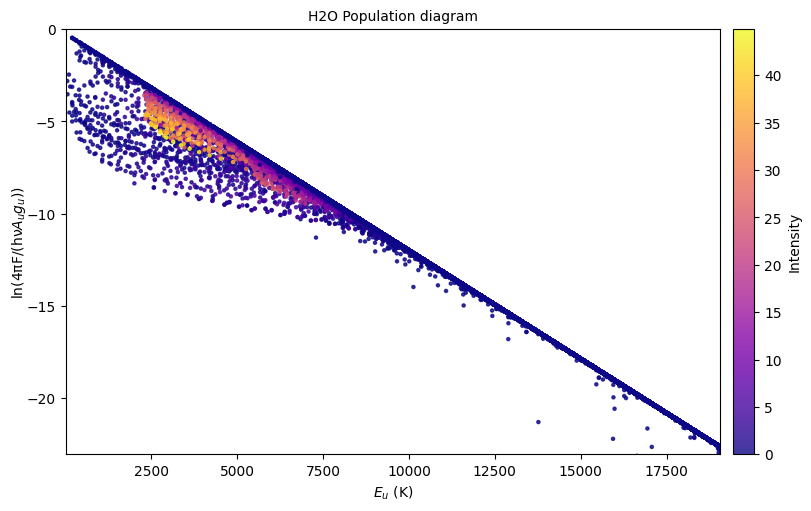

In [11]:
# --- Colour by model intensity ---
# Reveals which points contribute most to the observed spectrum

pdp_intens = PopulationDiagramPlot(
    molecule=mol_dict["H2O"],
    figsize=(8, 5),
)
pdp_intens.generate_plot()
pdp_intens.color_by("intens", cmap="plasma")
pdp_intens.show()

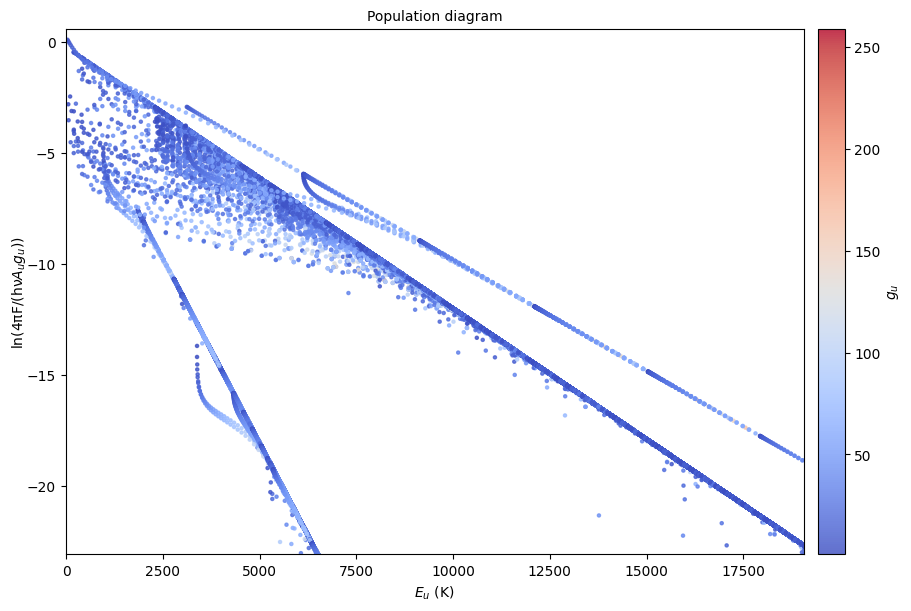

In [12]:
# --- Colour mapping works on multi-molecule diagrams too ---
# Here we colour all molecules by upper-state degeneracy

pdp_multi_cmap = PopulationDiagramPlot(
    molecules=mol_dict,
    figsize=(9, 6),
)
pdp_multi_cmap.generate_plot()
pdp_multi_cmap.color_by("g_up", cmap="coolwarm")
pdp_multi_cmap.show()

---
## 7. Colour Mapping — Categorical Properties

For categorical properties, each unique value gets a distinct colour and a legend
is shown instead of a colourbar.

This is especially useful for **molecule identity** — since single-molecule mode
defaults to a neutral grey, `color_by("molecule")` lets you opt into the molecule's
own colour, and in multi-molecule mode it gives each molecule a distinct legend entry.

### Supported categorical properties:

| `prop` value | Description |
|---|---|
| `'molecule'` | Which molecule the point belongs to (alias for `'component'`) |
| `'component'` | Same as `'molecule'` |
| `'lev_up'` | Upper quantum-state label |
| `'lev_low'` | Lower quantum-state label |

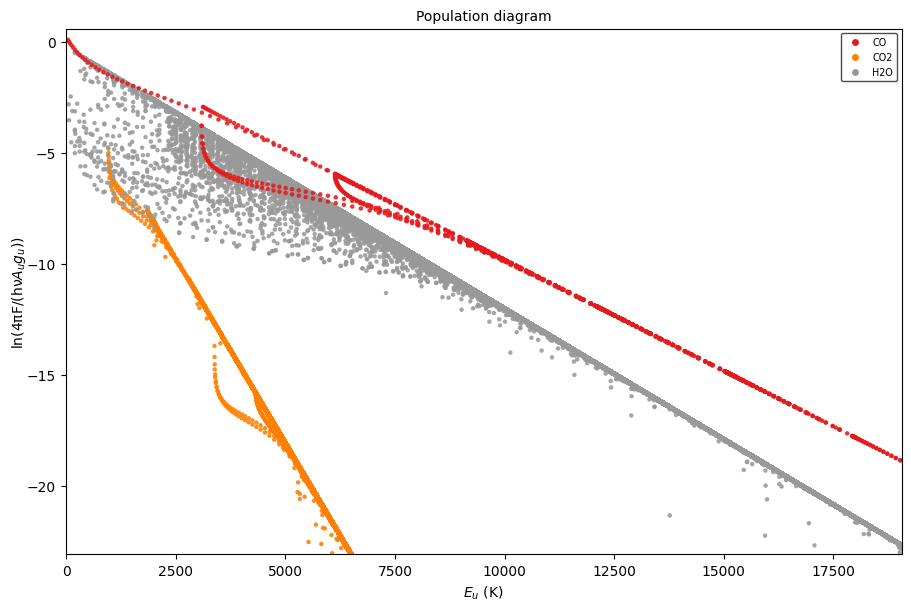

In [13]:
# --- Colour by molecule identity on multi-molecule diagram ---
# "molecule" is a convenience alias for "component"

pdp_mol = PopulationDiagramPlot(
    molecules=mol_dict,
    figsize=(9, 6),
)
pdp_mol.generate_plot()
pdp_mol.color_by("molecule", cmap="Set1")
pdp_mol.show()

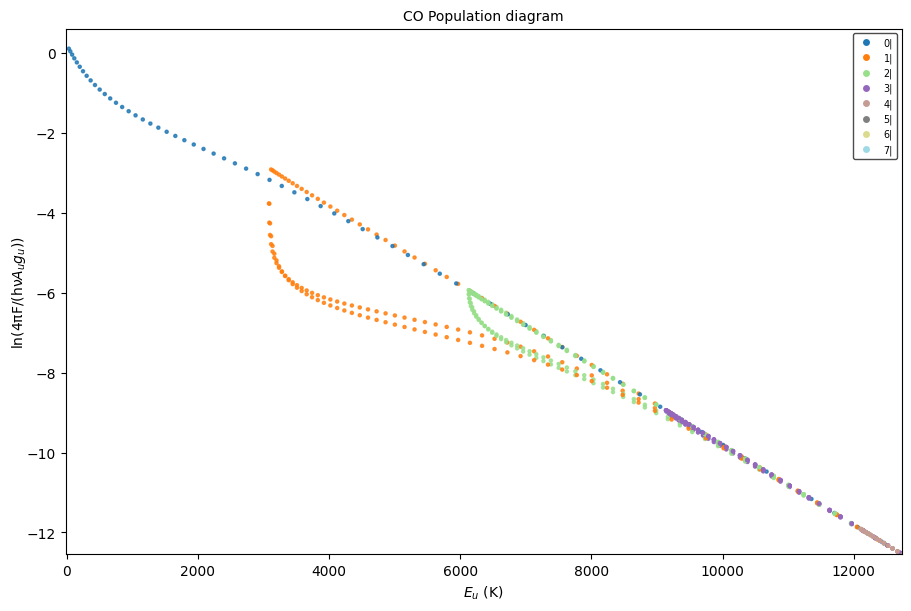

In [14]:
# --- Colour by upper quantum-state label ---
# Note: this can generate many categories for water, so the legend
# is capped at 20 entries with a "... +N more" note.

pdp_lev = PopulationDiagramPlot(
    molecule=mol_dict["CO"],   # CO has fewer upper-level labels
    figsize=(9, 6),
)
pdp_lev.generate_plot()
pdp_lev.color_by("lev_up", cmap="tab20")
pdp_lev.show()

---
## 8. Custom vmin / vmax

For continuous colour mapping, you can set explicit colour-scale limits
to highlight a specific range of values.

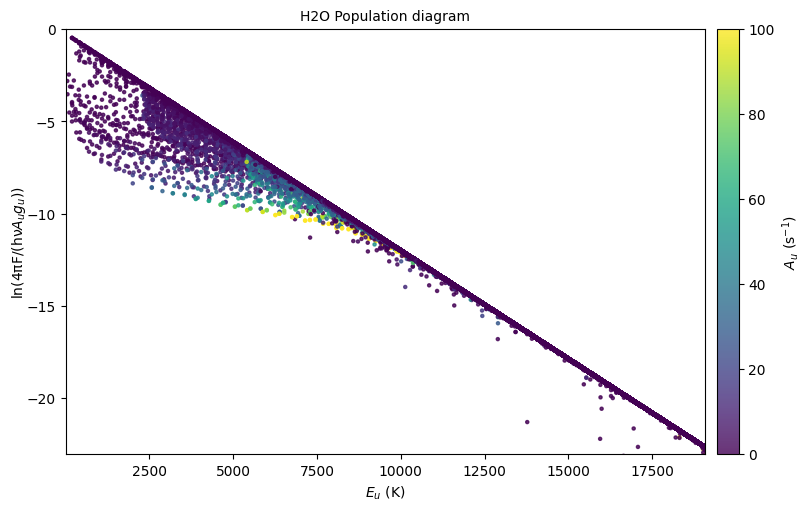

In [15]:
# --- Restrict the colour scale to a subrange ---

pdp_clip = PopulationDiagramPlot(
    molecule=mol_dict["H2O"],
    figsize=(8, 5),
)
pdp_clip.generate_plot()

# Only colour-map A_stein from 0 to 100 s^-1
pdp_clip.color_by("a_stein", cmap="viridis", vmin=0, vmax=100)
pdp_clip.show()

---
## 9. Dynamic Mutation

You can add, remove, or replace molecules **after** the plot has been created.
Each mutator method automatically regenerates the plot.

Starting with H2O only:


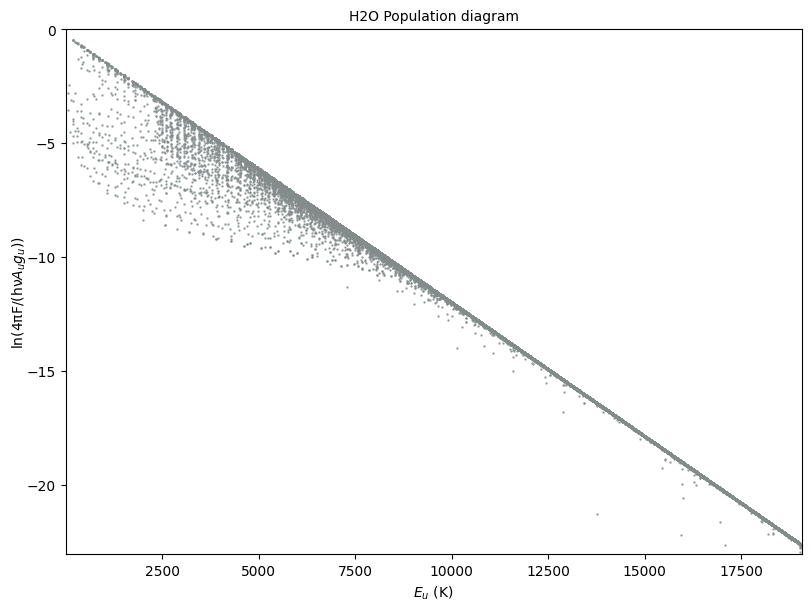

In [16]:
# --- Start with a single molecule, then add more ---

pdp_dyn = PopulationDiagramPlot(
    molecule=mol_dict["H2O"],
    figsize=(8, 6),
)
pdp_dyn.generate_plot()
print("Starting with H2O only:")
pdp_dyn.show()

After adding CO:


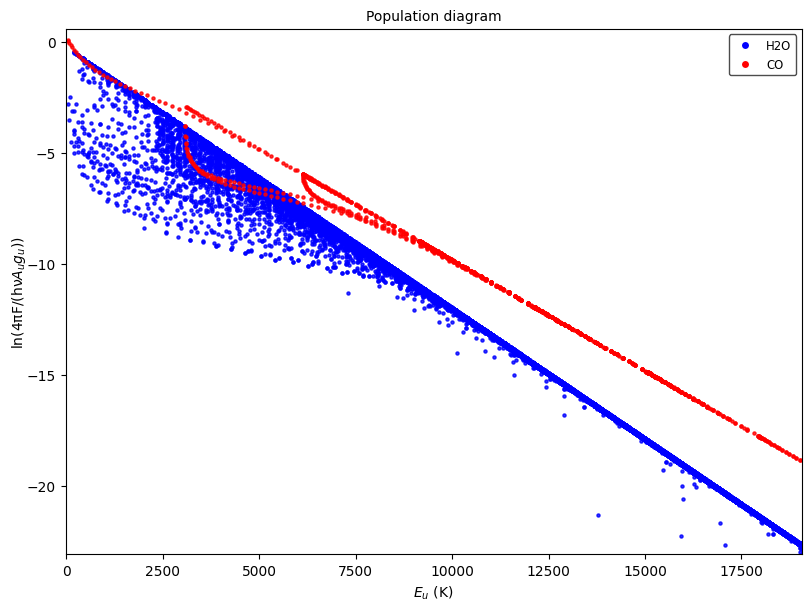

In [17]:
# --- add_molecule() converts from single to multi-molecule mode ---

pdp_dyn.add_molecule(mol_dict["CO"])
print("After adding CO:")
pdp_dyn.show()

After adding CO2:


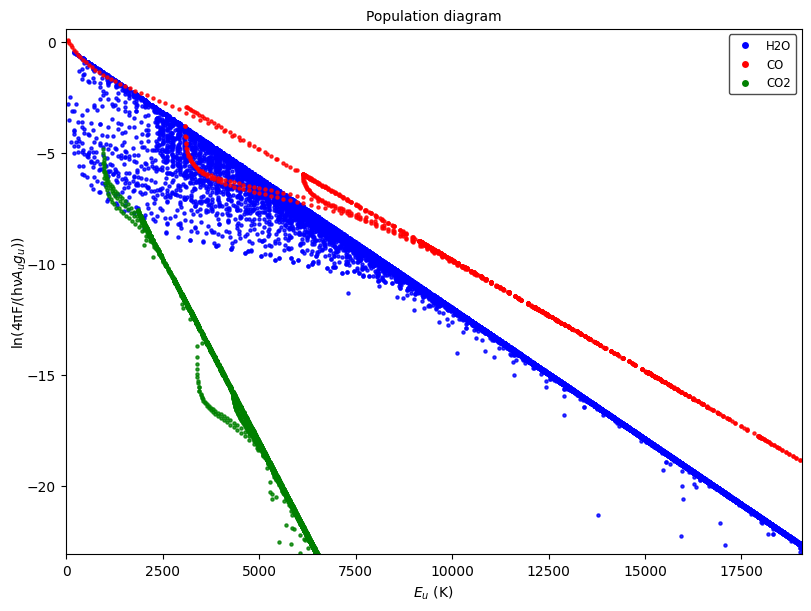

In [18]:
# --- Add CO2 as well ---

pdp_dyn.add_molecule(mol_dict["CO2"])
print("After adding CO2:")
pdp_dyn.show()

After removing CO:


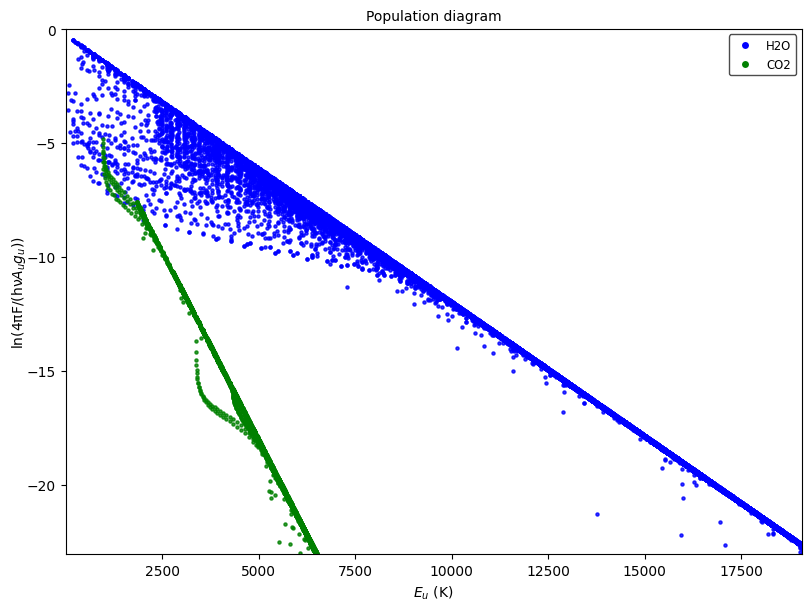

In [19]:
# --- remove_molecule() by name ---

pdp_dyn.remove_molecule("CO")
print("After removing CO:")
pdp_dyn.show()

After set_molecules([CO, CO2]):


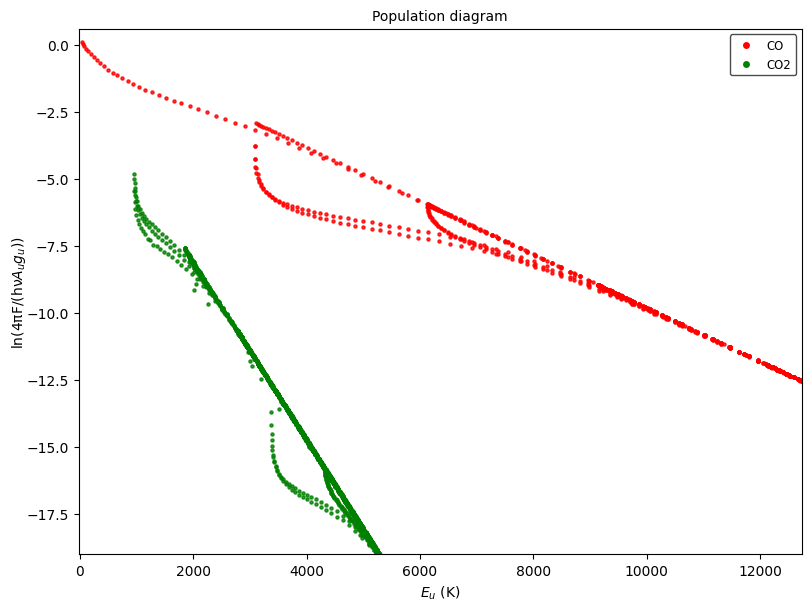

In [20]:
# --- set_molecules() replaces everything at once ---

pdp_dyn.set_molecules([mol_dict["CO"], mol_dict["CO2"]])
print("After set_molecules([CO, CO2]):")
pdp_dyn.show()

---
## 10. Clearing Colour Mapping

After applying `color_by()`, you can revert to the default per-component
colouring with `clear_color_mapping()`.

With colour mapping (A_stein):


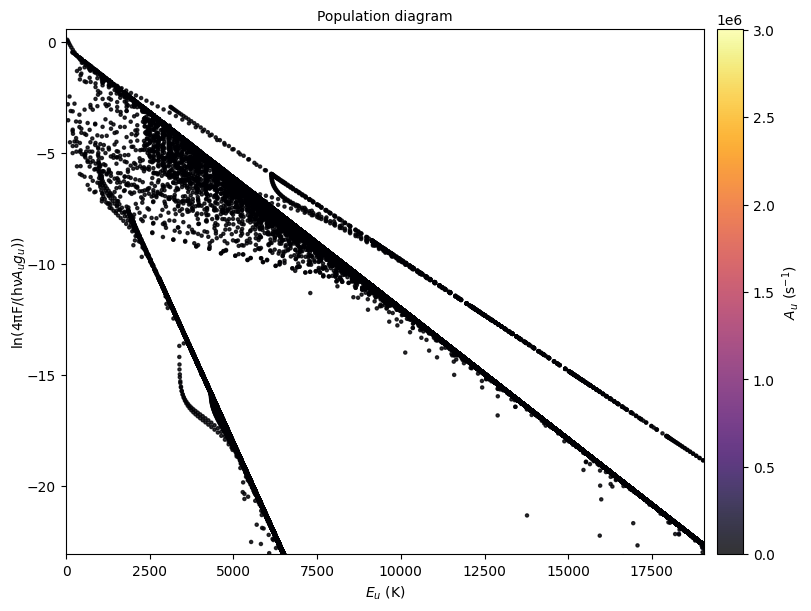

In [21]:
# --- Apply colour mapping then clear it ---

pdp_clear = PopulationDiagramPlot(
    molecules=mol_dict,
    figsize=(8, 6),
)
pdp_clear.generate_plot()

# Apply a colour map
pdp_clear.color_by("a_stein", cmap="inferno")
print("With colour mapping (A_stein):")
pdp_clear.show()

After clear_color_mapping():


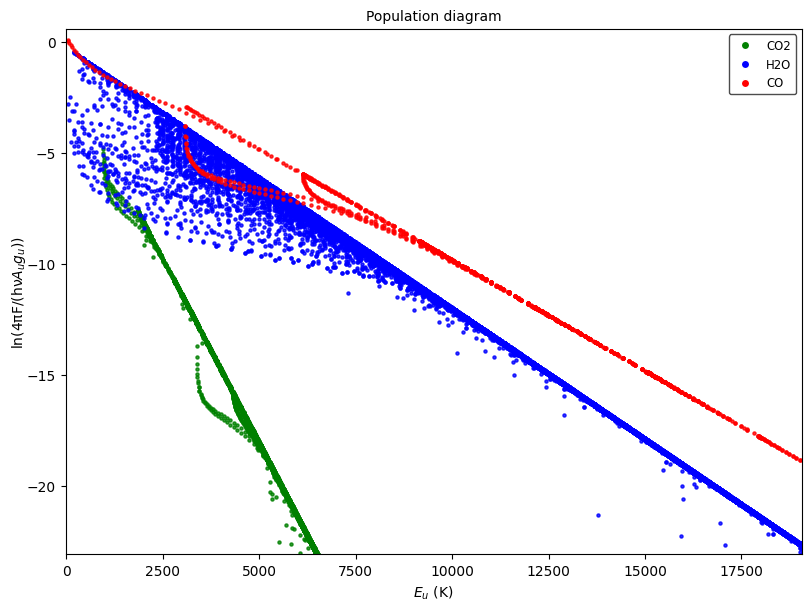

In [22]:
# --- Revert to per-component colouring ---

pdp_clear.clear_color_mapping()   # regenerates automatically
print("After clear_color_mapping():")
pdp_clear.show()

---
## 11. Embedding in Custom Layouts

Pass an existing `matplotlib.Axes` via the `ax=` parameter to embed the population
diagram into a larger figure layout.

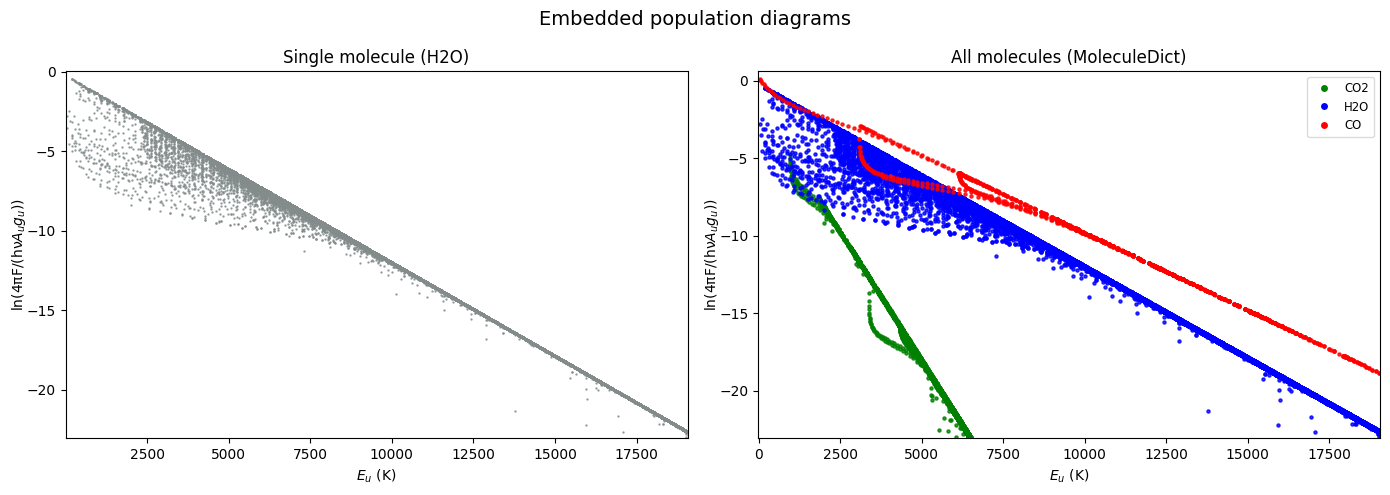

In [23]:
# --- Side-by-side: single-molecule vs multi-molecule ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: single molecule
pdp_left = PopulationDiagramPlot(
    molecule=mol_dict["H2O"],
    ax=axes[0],
)
pdp_left.generate_plot()
axes[0].set_title("Single molecule (H2O)")

# Right panel: all molecules
pdp_right = PopulationDiagramPlot(
    molecules=mol_dict,
    ax=axes[1],
)
pdp_right.generate_plot()
axes[1].set_title("All molecules (MoleculeDict)")

fig.suptitle("Embedded population diagrams", fontsize=14)
fig.tight_layout()
plt.show()

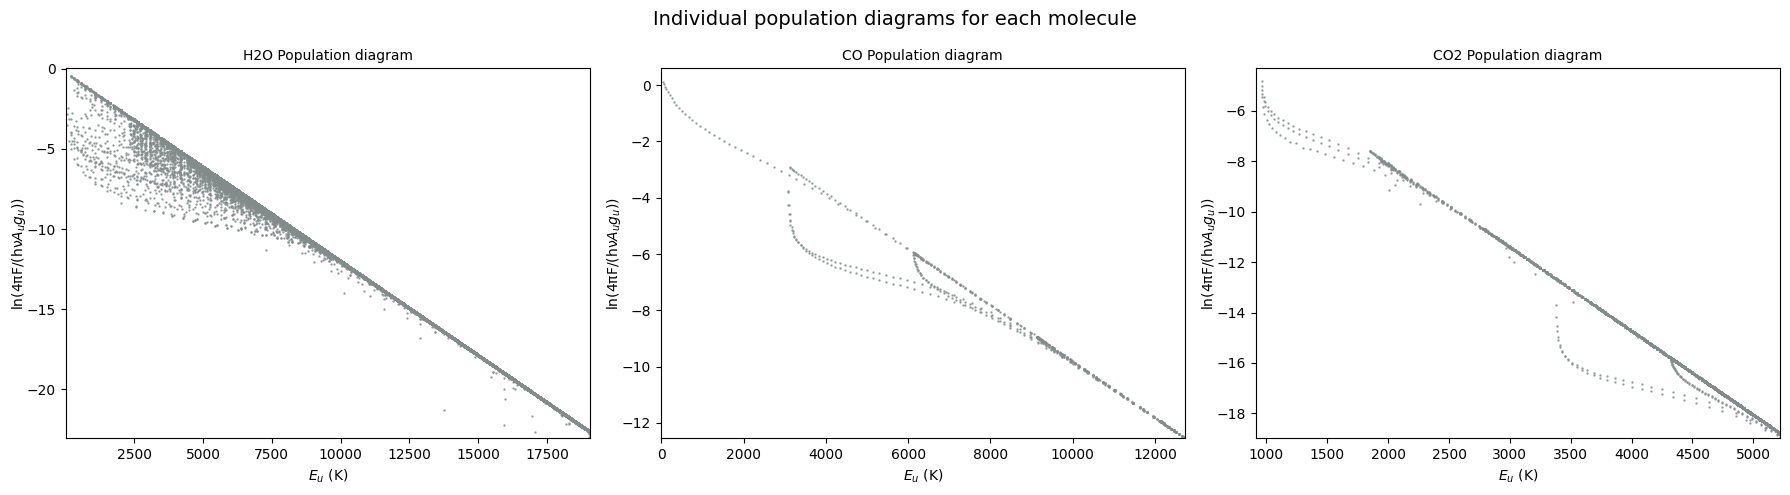

In [24]:
# --- Grid of per-molecule diagrams ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, mol_name in zip(axes, ["H2O", "CO", "CO2"]):
    pdp_each = PopulationDiagramPlot(molecule=mol_dict[mol_name], ax=ax)
    pdp_each.generate_plot()

fig.suptitle("Individual population diagrams for each molecule", fontsize=14)
fig.tight_layout()
plt.show()

---
## 12. MainPlotGrid Integration

`MainPlotGrid` creates a 3-panel composite: full spectrum (top), line inspection
(bottom-left), and population diagram (bottom-right).  When a `MoleculeDict` is
provided, the population diagram panel automatically shows all visible molecules.

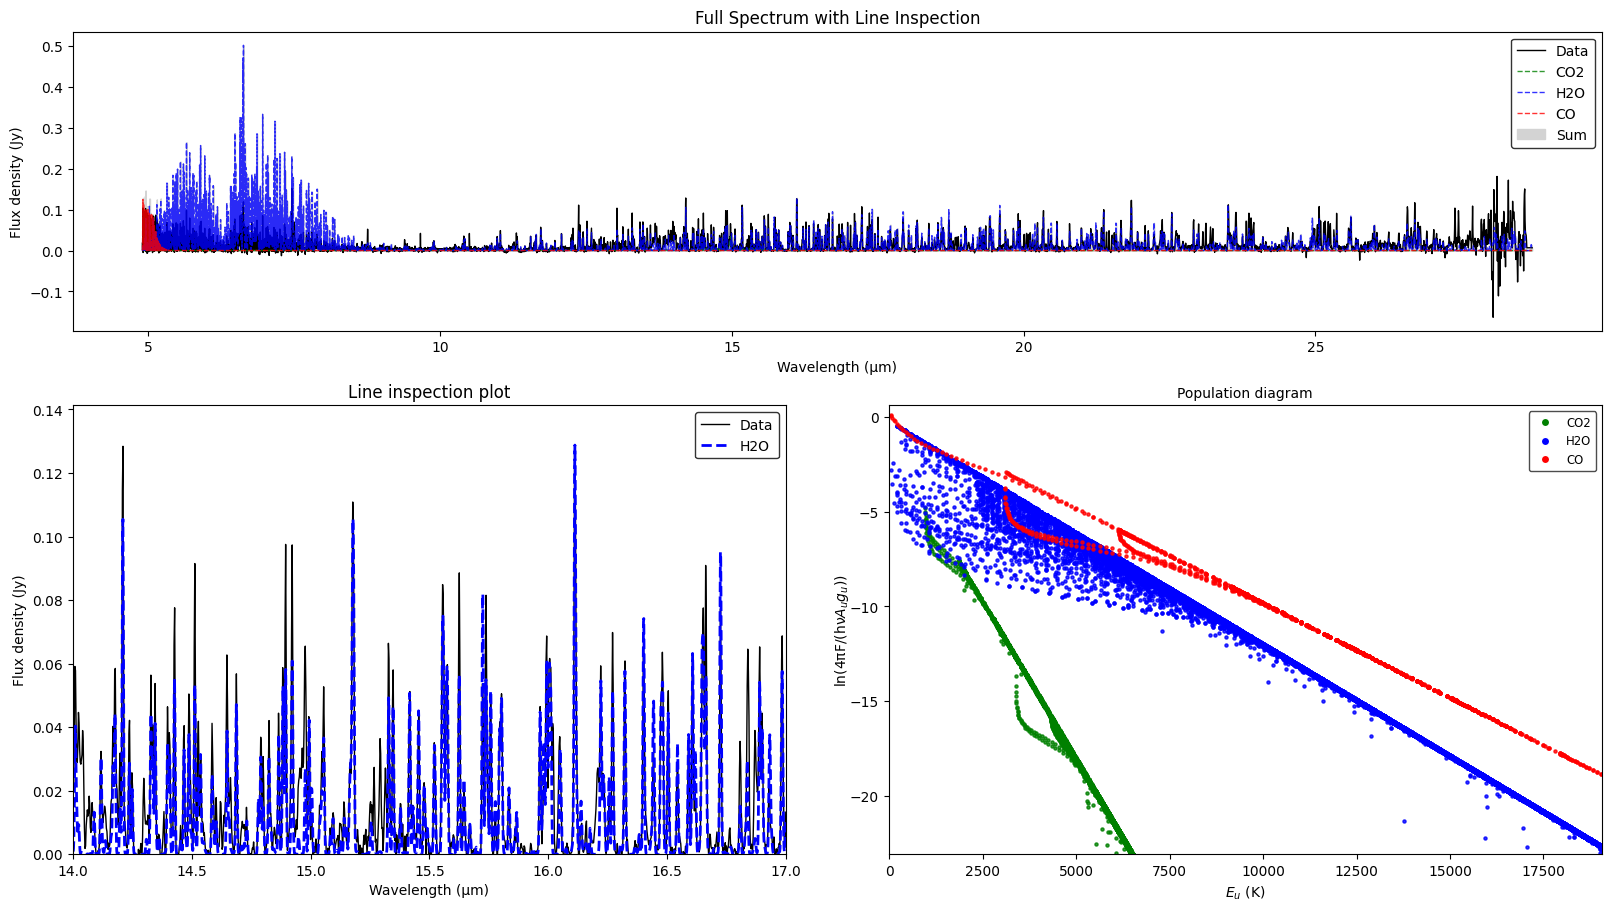

In [25]:
# --- MainPlotGrid with multi-molecule population diagram ---

grid = MainPlotGrid(
    wave_data=wave_grid,
    flux_data=observed_flux,
    molecules=mol_dict,
    active_molecule=mol_dict["H2O"],
    inspection_range=(14.0, 17.0),
    figsize=(16, 9),
)
grid.generate_plot()
grid.show()

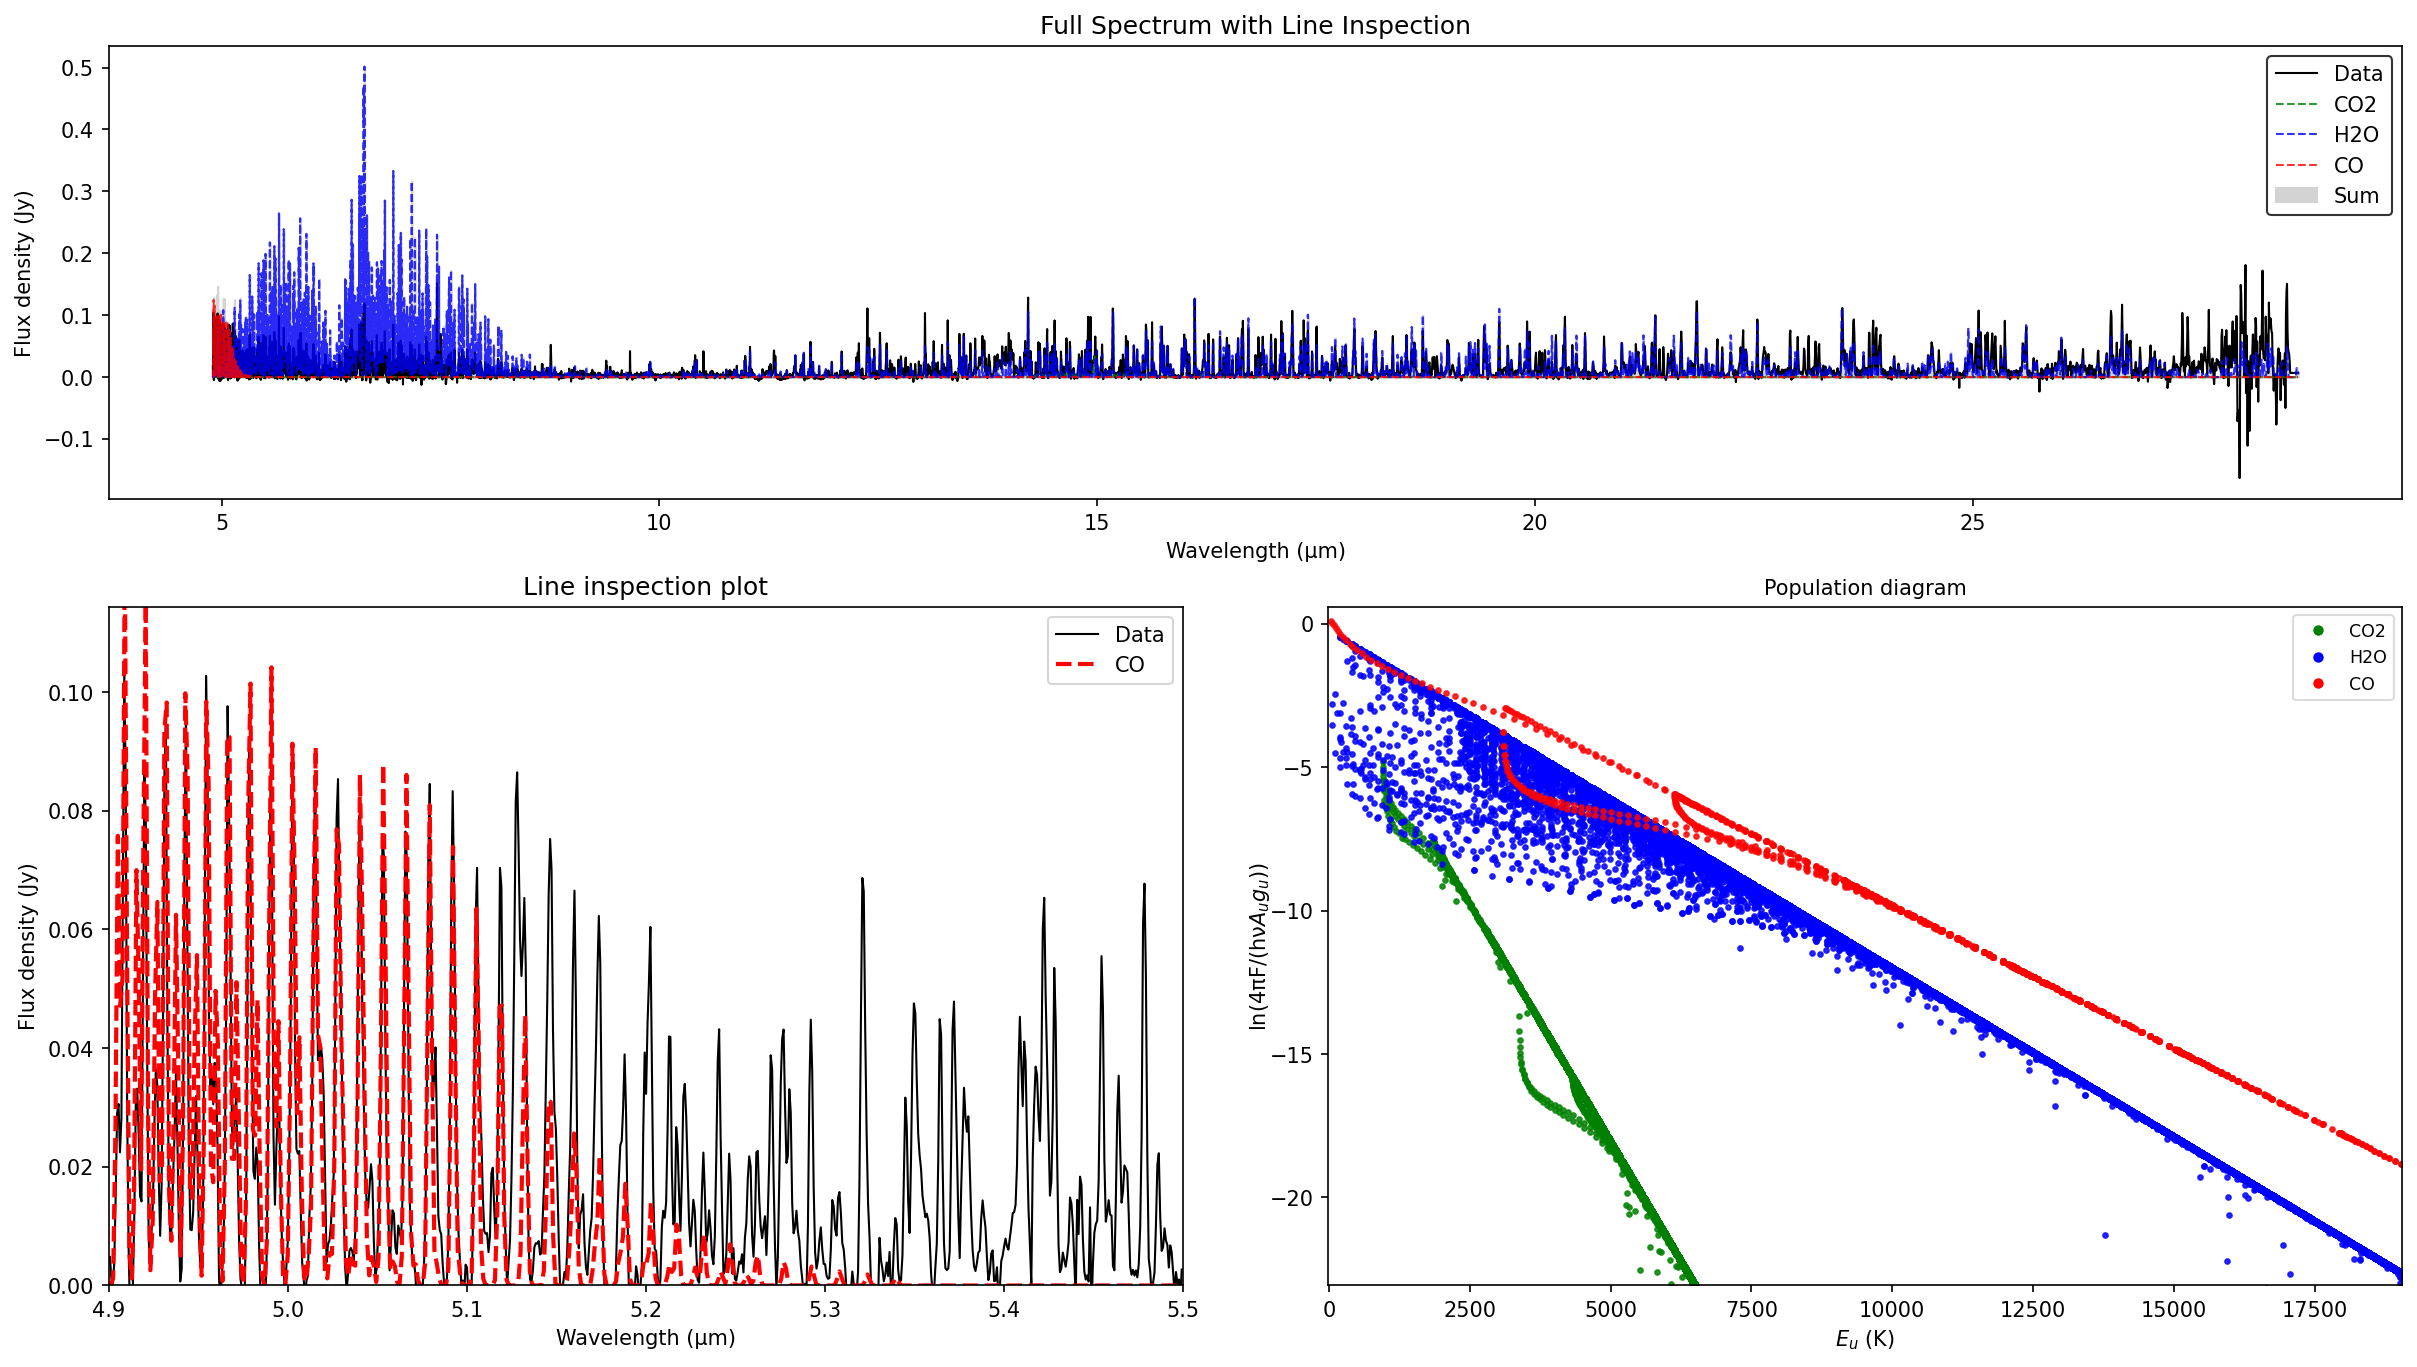

In [26]:
# --- Switch active molecule and re-display ---

grid.set_active_molecule(mol_dict["CO"])
grid.set_inspection_range(4.9, 5.5)
display(grid)

---
## 13. Theming

All plot classes accept a `theme` dictionary.  Use `load_theme()` to load
bundled themes or pass a custom dictionary.

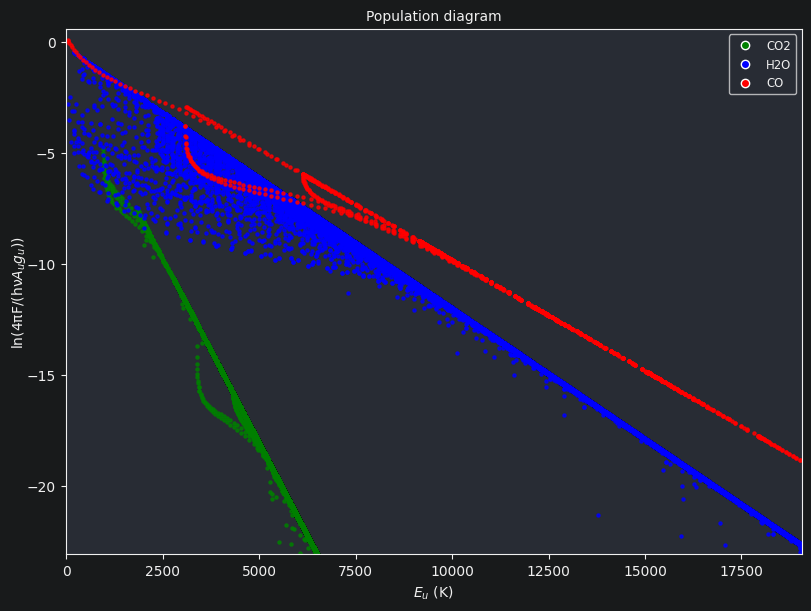

In [27]:
# --- Dark theme population diagram ---

dark_theme = load_theme("DarkTheme")

pdp_dark = PopulationDiagramPlot(
    molecules=mol_dict,
    theme=dark_theme,
    figsize=(8, 6),
)
pdp_dark.generate_plot()
pdp_dark.show()

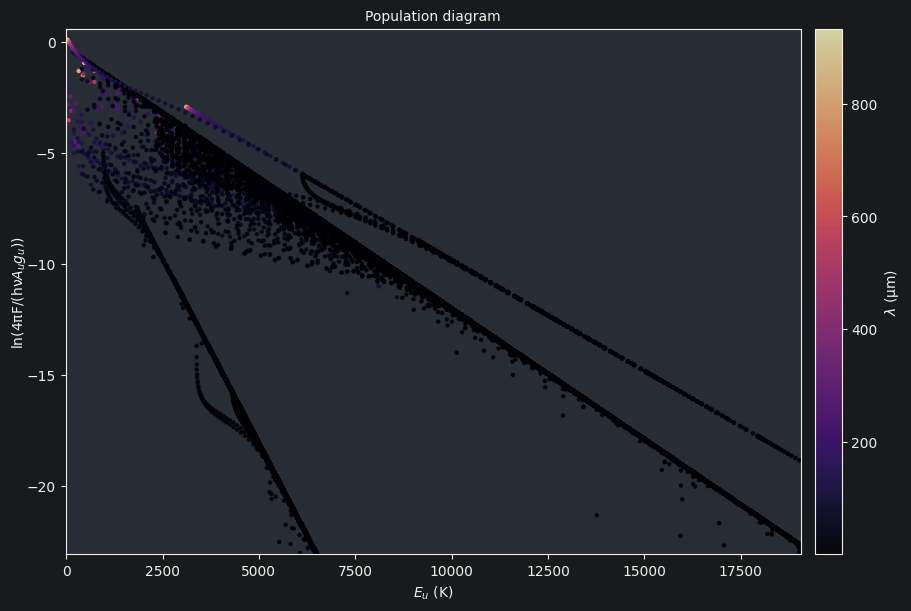

In [28]:
# --- Dark theme with colour mapping ---

pdp_dark_cmap = PopulationDiagramPlot(
    molecules=mol_dict,
    theme=dark_theme,
    figsize=(9, 6),
)
pdp_dark_cmap.generate_plot()
pdp_dark_cmap.color_by("wavelength", cmap="magma")
pdp_dark_cmap.show()

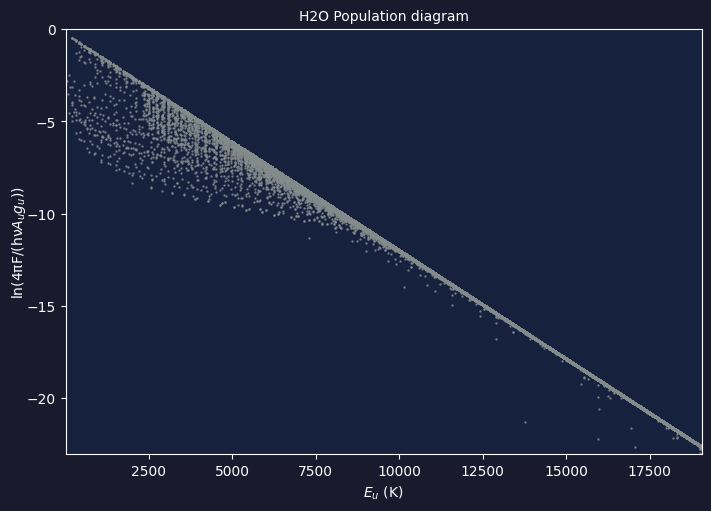

In [29]:
# --- Custom theme dictionary ---

my_theme = {
    "foreground": "white",
    "background": "#1a1a2e",
    "graph_fill_color": "#16213e",
    "active_scatter_line_color": "lime",
}

pdp_custom = PopulationDiagramPlot(
    molecule=mol_dict["H2O"],
    theme=my_theme,
    figsize=(7, 5),
)
pdp_custom.generate_plot()
pdp_custom.show()

---
## 14. Accessing Component Data

After `generate_plot()`, the `component_data` property exposes the computed
per-component data as a list of dictionaries.  Each dict contains arrays for
`eu`, `rd_yax`, `wavelength`, `intens`, `a_stein`, `g_up`, `lev_up`,
`lev_low`, `e_low`, `valid_mask`, and more.

This is useful for downstream analysis or custom plotting.

In [30]:
# --- Inspect component data ---

pdp_data = PopulationDiagramPlot(
    molecules=mol_dict,
    figsize=(8, 6),
)
pdp_data.generate_plot()

print(f"Number of components: {len(pdp_data.component_data)}\n")

for comp in pdp_data.component_data:
    n_total = len(comp["eu"])
    n_valid = int(np.sum(comp["valid_mask"]))
    eu_range = (np.nanmin(comp["eu"]), np.nanmax(comp["eu"]))
    print(f"  {comp['name']:8s}  color={comp['color']:8s}  "
          f"lines={n_total}  valid={n_valid}  "
          f"E_u range={eu_range[0]:.0f}-{eu_range[1]:.0f} K")

Number of components: 3

  CO2       color=green     lines=173129  valid=540  E_u range=961-25746 K
  H2O       color=#0000FF   lines=305561  valid=4925  E_u range=53-50404 K
  CO        color=#FF0000   lines=1334  valid=334  E_u range=33-22340 K


In [31]:
# --- Convert component data to a DataFrame for further analysis ---

rows = []
for comp in pdp_data.component_data:
    for i in range(len(comp["eu"])):
        rows.append({
            "component": comp["name"],
            "eu_K": comp["eu"][i],
            "rd_yax": comp["rd_yax"][i],
            "wavelength_um": comp["wavelength"][i],
            "a_stein": comp["a_stein"][i],
            "valid": comp["valid_mask"][i],
        })

df_pop = pd.DataFrame(rows)
print(f"Total rows: {len(df_pop)}")
print(f"Valid rows: {df_pop['valid'].sum()}")
print()
df_pop.head(10)

Total rows: 480024
Valid rows: 5799



,component,eu_K,rd_yax,wavelength_um,a_stein,valid
0,CO2,5035.62793,-18.180908,63.17048,0.000002,False
1,CO2,5002.60352,-18.070828,63.15716,0.000002,False
2,CO2,4973.57422,-17.974062,62.73488,0.000002,False
3,CO2,4943.00342,-17.872159,62.68657,0.000002,False
4,CO2,4916.02832,-17.782242,62.29272,0.000002,False
5,CO2,4887.89697,-17.688470,62.21253,0.000002,False
6,CO2,4862.99072,-17.605455,61.84433,0.000002,False
7,CO2,4837.28516,-17.519761,61.73531,0.000002,False
8,CO2,4814.46387,-17.443691,61.39006,0.000002,False
9,CO2,4791.16797,-17.366041,61.25520,0.000002,False


---
## Quick Reference

### Constructor parameters

| Parameter | Type | Description |
|-----------|------|-------------|
| `molecule` | `Molecule` | Single molecule (classic API) |
| `molecules` | `list[Molecule]` \| `MoleculeDict` | Multiple molecules to overlay |
| `intensity` | `Intensity` | Bare intensity object (requires `radius`, `distance`) |
| `name` | `str` | Display name when using bare intensity |
| `color` | `str` | Marker colour when using bare intensity |
| `radius` | `float` | Emitting radius in AU |
| `distance` | `float` | Distance in pc |
| `highlight_lines` | `list` | `(MoleculeLine, intensity, tau)` tuples |
| `figsize` | `tuple` | Figure size (default `(6, 5)`) |
| `ax` | `Axes` | Pre-existing axes for embedding |
| `theme` | `dict` | Theme dictionary |

> **Note:** `molecule`, `molecules`, and `intensity` are mutually exclusive.
>
> **Default colour:** Single-molecule mode uses the theme's `scatter_main_color` (neutral grey).
> Multi-molecule mode automatically assigns each molecule its own colour.
> Use `color_by("molecule")` to explicitly colour by molecule identity.

### Methods

| Method | Description |
|--------|-------------|
| `generate_plot()` | Build / refresh the diagram |
| `show()` | Display the plot |
| `save(path, dpi=...)` | Export to file |
| `close()` | Free figure memory |
| `color_by(prop, cmap=, vmin=, vmax=)` | Colour-map by molecular property |
| `clear_color_mapping()` | Revert to default colouring |
| `set_molecule(mol)` | Switch to a single molecule |
| `set_molecules(mols)` | Switch to multiple molecules |
| `set_intensity(int, ...)` | Switch to a bare intensity object |
| `add_molecule(mol)` | Add a molecule (auto-converts to multi-mode) |
| `remove_molecule(name)` | Remove a molecule by name |

### `color_by()` property names

| Property | Type | Description |
|----------|------|-------------|
| `'a_stein'` | continuous | Einstein A coefficient (s⁻¹) |
| `'wavelength'` / `'lam'` | continuous | Line wavelength (μm) |
| `'intens'` | continuous | Model intensity |
| `'g_up'` | continuous | Upper-state degeneracy |
| `'g_low'` | continuous | Lower-state degeneracy |
| `'e_up'` | continuous | Upper-level energy (K) — *same as x-axis* |
| `'e_low'` | continuous | Lower-level energy (K) |
| `'molecule'` | categorical | Molecule / component identity |
| `'component'` | categorical | Alias for `'molecule'` |
| `'lev_up'` | categorical | Upper quantum-state label |
| `'lev_low'` | categorical | Lower quantum-state label |